# Experiments on Modelling Between 2019 and 2025 Snapshots

This notebook is for investigating how models perform when extending the dataset to include two snapshots instead ofone.

There are two years with published IMD scores from the ONS, these being 2019 and 2025. Unfortunately, due to changing methodologies, direct score comparison cannot be made between the two but LSOA rankings are viable. Due to this, validation will have to be against rank even if training is on score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso

from scipy.stats import spearmanr

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 19

## Load and Clean Datasets

### Load Datasets

In [2]:
# Load dataset and imd to create merged dataset with target variable

indicators_2019 = pd.read_parquet("combined_indicators_2019.parquet", engine="fastparquet")
indicators_2025 = pd.read_parquet("combined_indicators_2025.parquet", engine="fastparquet")

scores_2019 = pd.read_csv("imd_2019_scores.csv")
scores_2025 = pd.read_csv("imd_2025_scores.csv")

lsoa_lookup = pd.read_csv("lsoa_2011_2021_lookup.csv")



### Clean Datasets

In [3]:
scores_2019.rename(columns={"LSOA code (2011)": "lsoa_code_11",
                           "Index of Multiple Deprivation (IMD) Score": "imd_score"
                          }, inplace=True)

# lsoa codes were changed in 2021, so 2019 codes are converted to 2021 codes using the lookup table
scores_2019 = scores_2019.merge(lsoa_lookup[["lsoa_code_11", "lsoa_code_21"]], on="lsoa_code_11", how="right")
scores_2019.drop(columns=["lsoa_code_11"], inplace=True)
scores_2019.rename(columns={"lsoa_code_21": "lsoa_code"}, inplace=True)


scores_2025.rename(columns={"LSOA code (2021)": "lsoa_code",
                           "Index of Multiple Deprivation (IMD) Score": "imd_score"
                          }, inplace=True)

scores_2019 = scores_2019[["lsoa_code", "imd_score"]]
scores_2025 = scores_2025[["lsoa_code", "imd_score"]]

# Merge features and target datasets on "lsoa_code"
data_2019 = pd.merge(indicators_2019, scores_2019, on="lsoa_code")
data_2025 = pd.merge(indicators_2025, scores_2025, on="lsoa_code", how="left")

#### Drop Missaligned Features

In [4]:
# Ensure features are consistent between datasets
common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
data_2019 = data_2019[common_features]
data_2025 = data_2025[common_features]

In [5]:
# Check that now datasets have the same shape
data_2019.shape == data_2025.shape   

True

#### Deal with Null, NaN and Inf

First infinite values are replaced with NaN

In [6]:
if np.isinf(data_2019.select_dtypes(include=["number"])).sum().sum()>0:
    print("Warning: Infinite values found in 2019 dataset, replaced with NaN.")
    data_2019.replace([np.inf, -np.inf], np.nan, inplace=True) 

if np.isinf(data_2025.select_dtypes(include=["number"])).sum().sum()>0:
    print("Warning: Infinite values found in 2025 dataset.")
    data_2025.replace([np.inf, -np.inf], np.nan, inplace=True)

Check missingness and drop features with >20% missing values, then impute remaining missing values with median

In [7]:
# 2019

missingness = data_2019.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2019)) * 100
missingness_df_2019 = pd.DataFrame({
    "feature": missingness.index,
    "missing_count": missingness.values,
    "missing_percent": missingness_percent.values
})

data_2019 = data_2019.drop(columns=missingness_df_2019[missingness_df_2019["missing_percent"] > 20]["feature"])
data_2019 = data_2019.fillna(data_2019.median(numeric_only=True)) 

missingness_df_2019.sort_values("missing_percent", ascending=False).head(10)

,feature,missing_count,missing_percent
0,resolution_rate,268,100.000000
1,ratio_fast_food_takeaway_to_food_dining_500,36,13.432836
2,ratio_sustainable_transport_to_transport_car_1000,27,10.074627
3,ratio_fast_food_takeaway_to_healthcare_access_...,22,8.208955
4,ratio_alcohol_gambling_to_financial_services_500,22,8.208955
5,burglary,9,3.358209
6,possession-of-weapons,9,3.358209
7,Awaiting court outcome,9,3.358209
8,Local resolution,9,3.358209
9,shoplifting,9,3.358209


In [8]:
# 2025

missingness = data_2025.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2025)) * 100
missingness_2025_df = pd.DataFrame({
    "feature": missingness.index,
    "missing_count": missingness.values,
    "missing_percent": missingness_percent.values
})

data_2025 = data_2025.drop(columns=missingness_2025_df[missingness_2025_df["missing_percent"] > 20]["feature"])
data_2025 = data_2025.fillna(data_2025.median(numeric_only=True)) 

missingness_2025_df.sort_values("missing_percent", ascending=False).head(10)

,feature,missing_count,missing_percent
0,landuse_garages_0,0,0.0
1,nearest_hospital,0,0.0
2,count_essential_services_1250,0,0.0
3,count_childcare_early_years_500,0,0.0
4,count_public_services_civic_500,0,0.0
5,count_education_skills_2500,0,0.0
6,nearest_bar,0,0.0
7,nearest_gambling,0,0.0
8,landuse_depot_0,0,0.0
9,count_financial_services_1250,0,0.0


In [9]:
# Ensure datasets still have the same shape after dropping features with high missingness
consistent_shape = data_2019.shape == data_2025.shape

print(f"Datasets have consistent shapes: {consistent_shape}")

if not consistent_shape:
    # redo the common features step to ensure both datasets have the same features after dropping those with high missingness
    common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
    data_2019 = data_2019[common_features]
    data_2025 = data_2025[common_features]


Datasets have consistent shapes: False


In [10]:
data_2019 = data_2019.sort_values(by="lsoa_code").set_index("lsoa_code")
data_2025 = data_2025.sort_values(by="lsoa_code").set_index("lsoa_code")

X_2019 = data_2019.drop(columns=["imd_score"])
y_2019 = data_2019["imd_score"]

X_2025 = data_2025.drop(columns=["imd_score"])
y_2025 = data_2025["imd_score"]

## Exploratory Analysis

### Target Distribution

Start by observing dsitribution on scores.

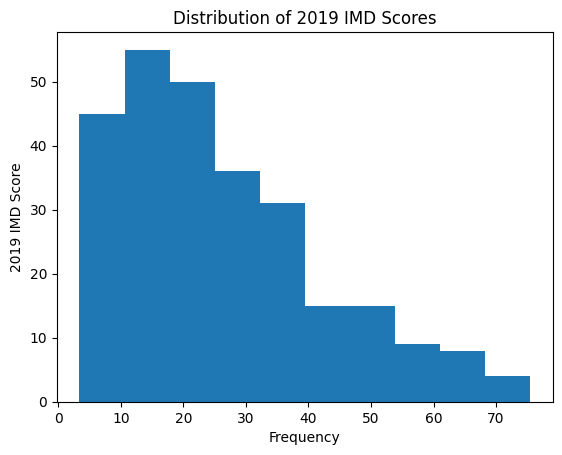

In [11]:
plt.figure()
plt.hist(y_2019, bins=10)
plt.ylabel("2019 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2019 IMD Scores")
plt.show()

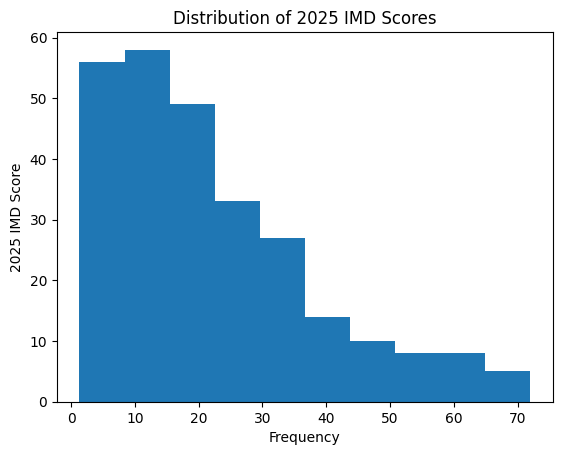

In [12]:
plt.figure()
plt.hist(y_2025, bins=10)
plt.ylabel("2025 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2025 IMD Scores")
plt.show()

Though as noted, methodology changed between the two reports, scores seem to follow similar scale and distribution. For modeling, the postive skew is removed with a log transformation.

In [13]:
y_log_2019 = np.log1p(y_2019)
y_log_2025 = np.log1p(y_2025)

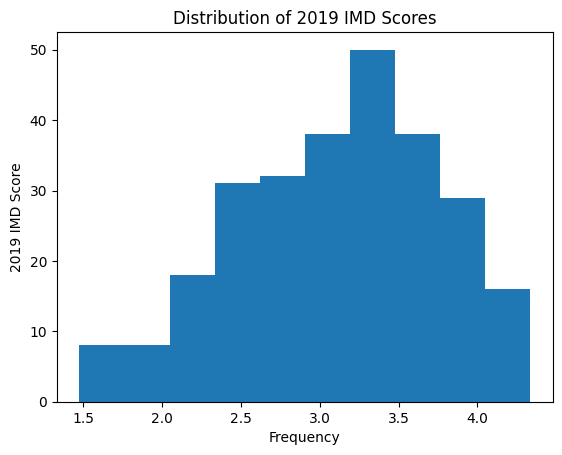

In [14]:
plt.figure()
plt.hist(y_log_2019, bins=10)
plt.ylabel("2019 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2019 IMD Scores")
plt.show()

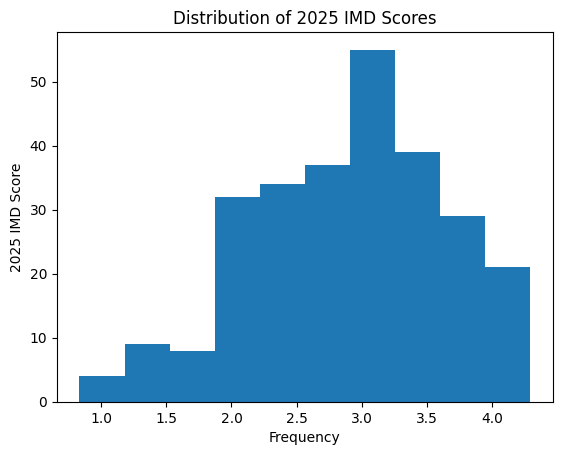

In [15]:
plt.figure()
plt.hist(y_log_2025, bins=10)
plt.ylabel("2025 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2025 IMD Scores")
plt.show()

Similarity in distribution is now even more striking. To check train and validation splits will have some difference, correlation and scatter of scores is checked.

In [16]:
corr, p_value = spearmanr(y_log_2019, y_log_2025)
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.9734030258815511
P-value: 2.931537012194532e-172


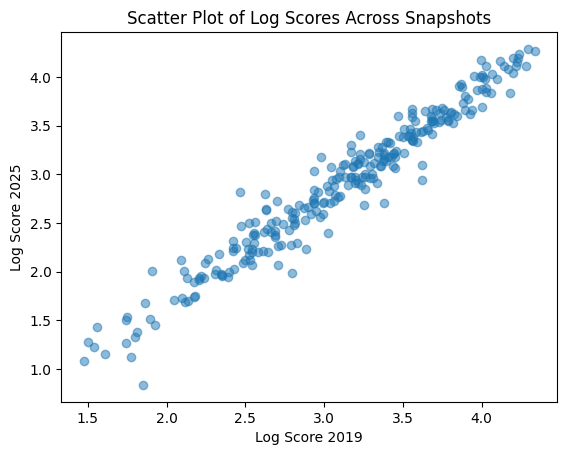

In [17]:
plt.scatter(y_log_2019, y_log_2025, alpha=0.5)
plt.xlabel("Log Score 2019")
plt.ylabel("Log Score 2025")
plt.title("Scatter Plot of Log Scores Across Snapshots")
plt.show()

A strong correlation between snapshot scores is slightly worrying. Though it is known that different methods were used to caclulate scores for the two dates, it seems lsoa scores line up pretty well. This means using one set for cross-validation and then the other as a hold out validation set may produce inflated metrics since the two snapshots targets are similar. Having said that, this is not to say that feature values will be similar also, even though intuitively they should be somewhat. This does also give more weight to metrics from cross-validation and so use of multiple model metrics is emphasised.

### Feature Correlations

In [18]:
numeric_features_2019 = data_2019.select_dtypes(include=["number"])
numeric_features_2025 = data_2025.select_dtypes(include=["number"])

print(numeric_features_2019.corr().shape, numeric_features_2025.corr().shape) # these should be the same from previous cleaning steps
print("total number of correlations:", numeric_features_2019.size)



(340, 340) (340, 340)
total number of correlations: 91120


Due to large shape visualising as a full heatmap would be innefective. Instead correlation is checked through tables.

In [19]:

corr_with_target_2019 = numeric_features_2019.corr()["imd_score"].abs().sort_values(ascending=False)
corr_with_target_2025 = numeric_features_2025.corr()["imd_score"].abs().sort_values(ascending=False)

corr_with_target_2019 = corr_with_target_2019.drop("imd_score")
corr_with_target_2025 = corr_with_target_2025.drop("imd_score")

print("With target (2019):",end="\n\n")
print(corr_with_target_2019.head(10))
print("\nWith target (2025):",end="\n\n")
print(corr_with_target_2025.head(10))


With target (2019):

total_nwr_claims              0.911166
mean_monthly_nwr_claims       0.911166
mean_monthly_claims           0.889190
total_claims                  0.889190
mean_monthly_prepfw_claims    0.834038
total_prepfw_claims           0.834038
total_planfw_claims           0.723200
mean_monthly_planfw_claims    0.723200
mean_monthly_sfw_claims       0.698193
total_sfw_claims              0.698193
Name: imd_score, dtype: float64

With target (2025):

mean_monthly_nwr_claims       0.930357
total_nwr_claims              0.930357
total_claims                  0.909689
mean_monthly_claims           0.909689
mean_monthly_prepfw_claims    0.860501
total_prepfw_claims           0.860501
total_planfw_claims           0.769796
mean_monthly_planfw_claims    0.769796
mean_monthly_sfw_claims       0.713258
total_sfw_claims              0.713258
Name: imd_score, dtype: float64


Seeing that correlation on UC metrics are almost perfect, a scatterplot is produced. Note that since correlation was taken against the non-log transformed target, the standard target is used for the plot too.

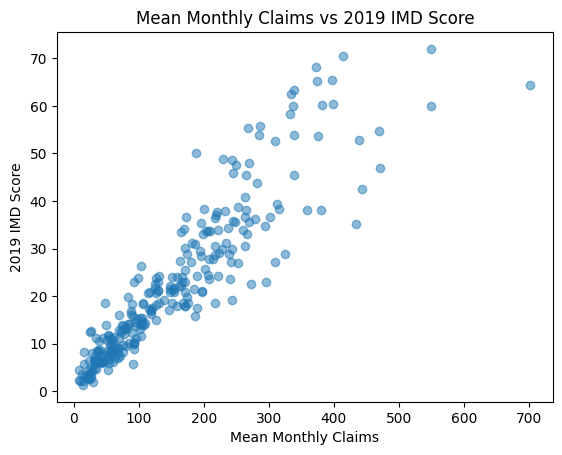

In [20]:
plt.scatter(data_2025[["mean_monthly_claims"]], y_2025, alpha=0.5)
plt.xlabel("Mean Monthly Claims")
plt.ylabel("2019 IMD Score")
plt.title("Mean Monthly Claims vs 2019 IMD Score")
plt.show()

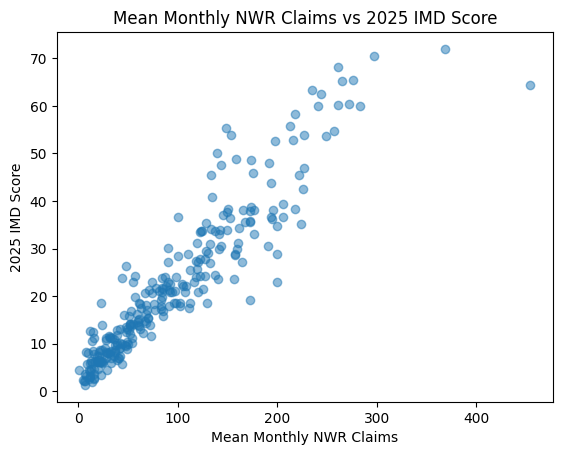

In [21]:
plt.scatter(data_2025[["mean_monthly_nwr_claims"]], y_2025, alpha=0.5)
plt.xlabel("Mean Monthly NWR Claims")
plt.ylabel("2025 IMD Score")  
plt.title("Mean Monthly NWR Claims vs 2025 IMD Score")
plt.show()

Seeing this, it is expected models should perform very well. Possibly to an extent which otherwise would appear to be overfitting. With a dataset of the shape p >> n, it was expected that the feature space would have to be reduced down by PCA, factor analysis or another method. On seeing these high correlations, it may even be sufficient to just select raw features using correlation scores or allow regularisation methods to perform feature selection. Regardless, both options will be explored. For PCA, correlations between features should be checked and UC features are expected to show up with significant coefficients.

In [22]:
corr_2019 = numeric_features_2019.corr().abs()
corr_2025 = numeric_features_2025.corr().abs()

def corr_count(corr_matrix, threshold):
    count = corr_matrix[corr_matrix > threshold].count().sum() - len(corr_matrix)  # subtract self-correlations
    return count

count_2019 = corr_count(corr_2019, 0.8)
count_2025 = corr_count(corr_2025, 0.8)

print(f"Number of feature pairs with absolute correlation > 0.8 in 2019: {count_2019}")
print(f"As a percentage of total correlations: {count_2019 / numeric_features_2019.size:.2%}", end="\n\n")

print(f"Number of feature pairs with absolute correlation > 0.8 in 2025: {count_2025}")
print(f"As a percentage of total correlations: {count_2025 / numeric_features_2025.size:.2%}")


Number of feature pairs with absolute correlation > 0.8 in 2019: 9681
As a percentage of total correlations: 10.62%

Number of feature pairs with absolute correlation > 0.8 in 2025: 7864
As a percentage of total correlations: 8.63%


Observing about a tenth of absoloute correlations in the feature space for both snapshots is over 0.8, analysis is repeated on a threshold of 0.5

In [23]:
count_2019 = corr_count(corr_2019, 0.5)
count_2025 = corr_count(corr_2025, 0.5)

print(f"Number of feature pairs with absolute correlation > 0.5 in 2019: {count_2019}")
print(f"As a percentage of total correlations: {count_2019 / numeric_features_2019.size:.2%}", end="\n\n")

print(f"Number of feature pairs with absolute correlation > 0.5 in 2025: {count_2025}")
print(f"As a percentage of total correlations: {count_2025 / numeric_features_2025.size:.2%}")

Number of feature pairs with absolute correlation > 0.5 in 2019: 31417
As a percentage of total correlations: 34.48%

Number of feature pairs with absolute correlation > 0.5 in 2025: 29528
As a percentage of total correlations: 32.41%


With this, about 30% of correlations are found to be of some importance.

These measures indicate high multicolinearity. While this may be less of an issue for tree-based models, regression models might be unstable. To accomodate for this, PCA will be used since it produces orthogonal features.

### Encode Categorical Features

Before modelling or feature reduction categorical features need to be encoded.

In [24]:
categorical_cols = data_2019.select_dtypes(include=["object", "category"]).columns
print("Categorical columns:", list(categorical_cols))

numeric_features_2019.shape, data_2019.shape

Categorical columns: []


((268, 340), (268, 340))

With no categorical features, encoding is not required.

## Modelling

In [25]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]
pca_components = [10, 20, 50, 75, 100]
fa_components = [10, 20, 50, 75, 100]

reducers = {
    "none": [None],
    "pca": pca_components,
    "fa": fa_components
}

models = {
    "ridge": lambda a: Ridge(alpha=a, random_state=42),
    "lasso": lambda a: Lasso(alpha=a, random_state=42, max_iter=10000),
}

dataset_pairs = [
    ("2019 -> 2025", X_2019, y_log_2019, X_2025, y_log_2025),
    ("2025 -> 2019", X_2025, y_log_2025, X_2019, y_log_2019),
]

In [26]:
results = []

for direction, X_train, y_train, X_test, y_test in dataset_pairs:

    for reducer_name, params in reducers.items():
        for param in params:

            if reducer_name == "pca":
                reducer = PCA(n_components=param)
            elif reducer_name == "fa":
                reducer = FactorAnalysis(n_components=param)
            else:
                reducer = "passthrough"

            for model_name, model_fn in models.items():

                alpha_values = alphas if model_name in ["ridge", "lasso"] else [None]

                for a in alpha_values:

                    model = model_fn(a)

                    pipe = Pipeline([
                        ("scaler", StandardScaler()),
                        ("reduce", reducer),
                        ("model", model)
                    ])


                    cv_results = cross_validate(
                        pipe,
                        X_train,
                        y_train,
                        cv=5,
                        scoring={
                            "r2": "r2",
                            "rmse": "neg_root_mean_squared_error"
                        },
                        n_jobs=-1,
                        return_train_score=False
                    )

                    # Extract metrics
                    r2_scores = cv_results["test_r2"]
                    rmse_scores = -cv_results["test_rmse"]  # flip sign

                    r2_mean = r2_scores.mean()
                    r2_std = r2_scores.std()

                    rmse_mean = rmse_scores.mean()
                    rmse_std = rmse_scores.std()

                    # Validation set
                    pipe.fit(X_train, y_train)
                    y_pred = pipe.predict(X_test)

                    spearman_rank, p = spearmanr(y_test, y_pred)

                    if p < 0.05:
                        results.append({
                            "direction": direction,
                            "model": model_name,
                            "alpha": a,
                            "reduction": reducer_name,
                            "reduction_param": param,
                            "cv_r2_mean": r2_mean,
                            "cv_r2_std": r2_std,
                            "cv_rmse_mean": rmse_mean,
                            "cv_rmse_std": rmse_std,
                            "val_spearman": spearman_rank,
                            "spearmen_p_value": p,
                        })

results_df = pd.DataFrame(results)

In [27]:
results_df.shape

(173, 11)

## Evaluation

In [28]:
results_df.sort_values(by="cv_r2_mean", ascending=False).head(5)

,direction,model,alpha,reduction,reduction_param,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,val_spearman,spearmen_p_value
6,2019 -> 2025,lasso,0.01,none,NaN,0.834715,0.059112,0.259247,0.062193,0.953132,4.011298e-140
97,2025 -> 2019,lasso,0.01,none,NaN,0.816235,0.134639,0.303045,0.126929,0.438194,5.315747e-14
135,2025 -> 2019,ridge,100.00,pca,100.0,0.813851,0.077290,0.311742,0.083755,0.412975,1.840124e-12
4,2019 -> 2025,ridge,100.00,none,NaN,0.811599,0.057865,0.277510,0.059188,0.907075,6.048118e-102
95,2025 -> 2019,ridge,100.00,none,NaN,0.806802,0.111093,0.314798,0.109564,0.383277,8.308805e-11


In [29]:
results_df.sort_values(by="val_spearman", ascending=False).head(5)

,direction,model,alpha,reduction,reduction_param,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,val_spearman,spearmen_p_value
7,2019 -> 2025,lasso,0.10,none,NaN,0.744565,0.076864,0.322991,0.068005,0.953767,6.827547e-141
6,2019 -> 2025,lasso,0.01,none,NaN,0.834715,0.059112,0.259247,0.062193,0.953132,4.011298e-140
60,2019 -> 2025,lasso,0.10,fa,10.0,0.673300,0.069213,0.366881,0.062813,0.946331,1.706744e-132
68,2019 -> 2025,lasso,0.10,fa,20.0,0.675222,0.062235,0.365961,0.058737,0.944422,1.567221e-130
91,2019 -> 2025,lasso,0.01,fa,100.0,0.780395,0.076688,0.298437,0.069804,0.943298,2.080422e-129


In [30]:
results_df.sort_values(by="cv_rmse_mean", ascending=True).head(5)

,direction,model,alpha,reduction,reduction_param,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,val_spearman,spearmen_p_value
6,2019 -> 2025,lasso,0.01,none,NaN,0.834715,0.059112,0.259247,0.062193,0.953132,4.011298e-140
4,2019 -> 2025,ridge,100.00,none,NaN,0.811599,0.057865,0.277510,0.059188,0.907075,6.048118e-102
48,2019 -> 2025,ridge,100.00,pca,100.0,0.795924,0.061919,0.289245,0.062041,0.908084,1.517962e-102
50,2019 -> 2025,lasso,0.01,pca,100.0,0.785030,0.068899,0.294950,0.063064,0.903593,6.344861e-100
47,2019 -> 2025,ridge,10.00,pca,100.0,0.787487,0.034584,0.296457,0.043850,0.895858,1.069013e-95


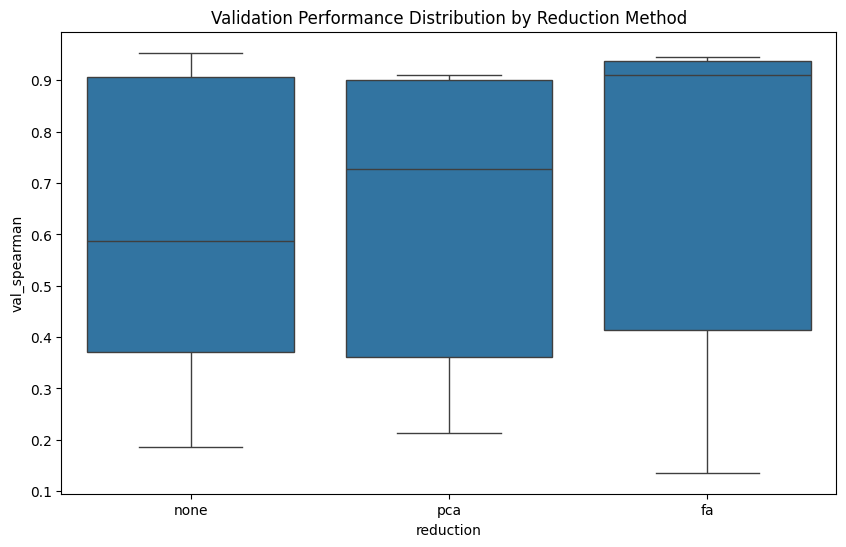

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x="reduction", y="val_spearman")
plt.title("Validation Performance Distribution by Reduction Method")
plt.show()

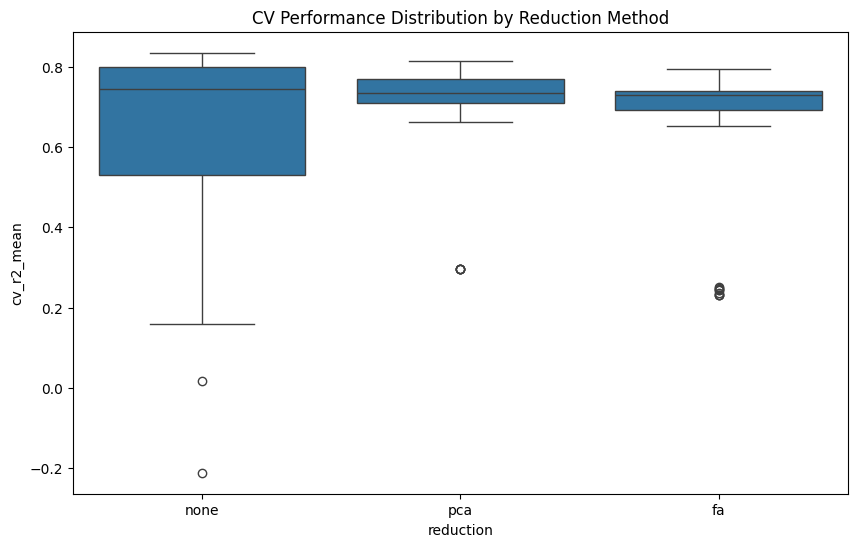

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x="reduction", y="cv_r2_mean")
plt.title("CV Performance Distribution by Reduction Method")
plt.show()

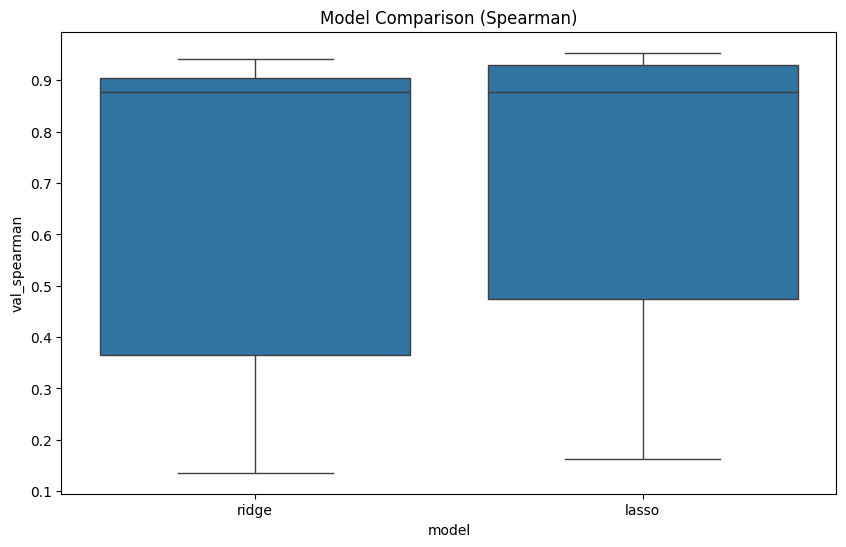

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x="model", y="val_spearman")
plt.title("Model Comparison (Spearman)")
plt.show()

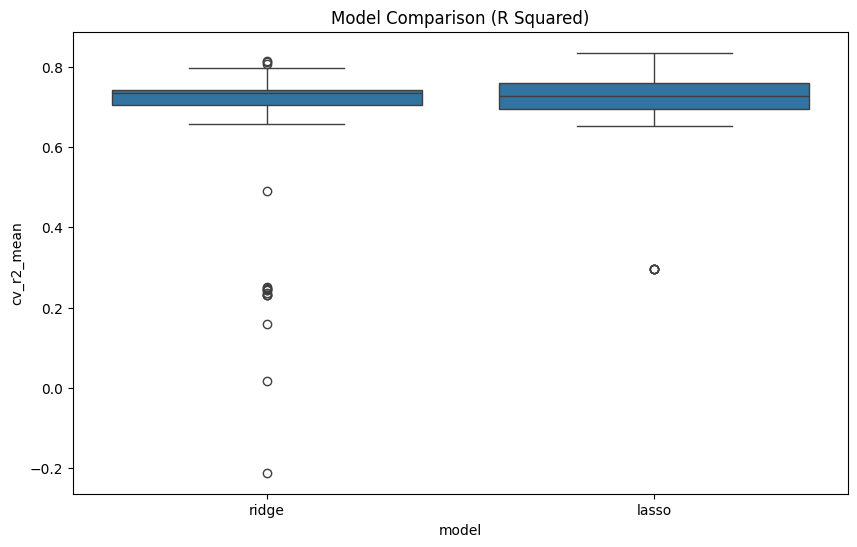

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x="model", y="cv_r2_mean")
plt.title("Model Comparison (R Squared)")
plt.show()

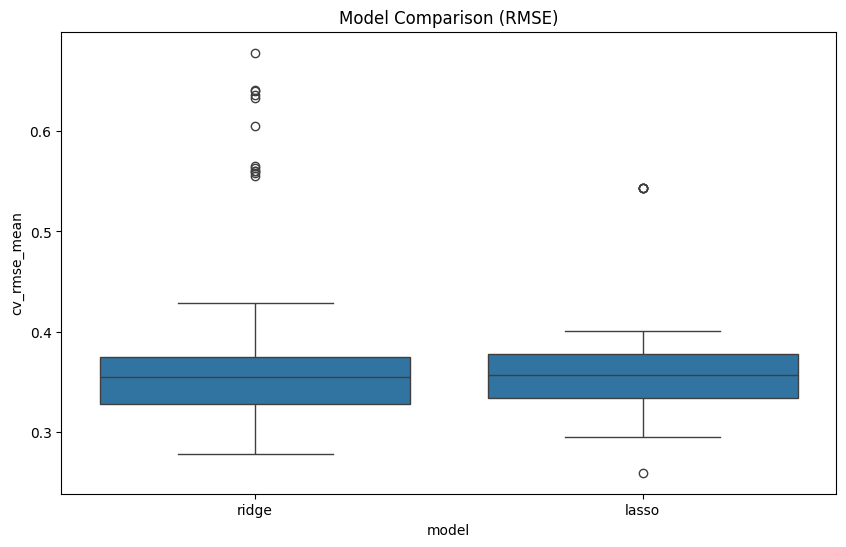

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x="model", y="cv_rmse_mean")
plt.title("Model Comparison (RMSE)")
plt.show()

Initial plots and tables on model performance is promising with most models judging by median lines on boxplots doing well. The purpose of this notebook however is less on selecting the most optimal model but rather showcasing the possibility for training and validating across different snapshots. To this end, now that overall good model performance is established (outside of considering overfitting), analysis shifts towards comparing the different directions for the train/test/validate splits. 

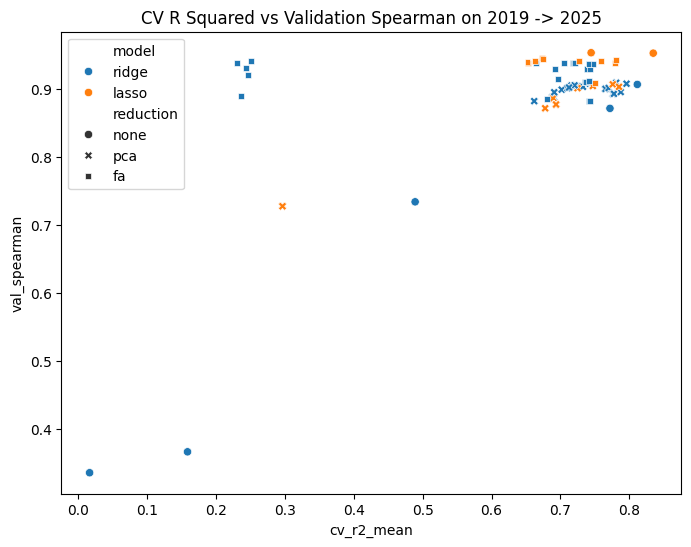

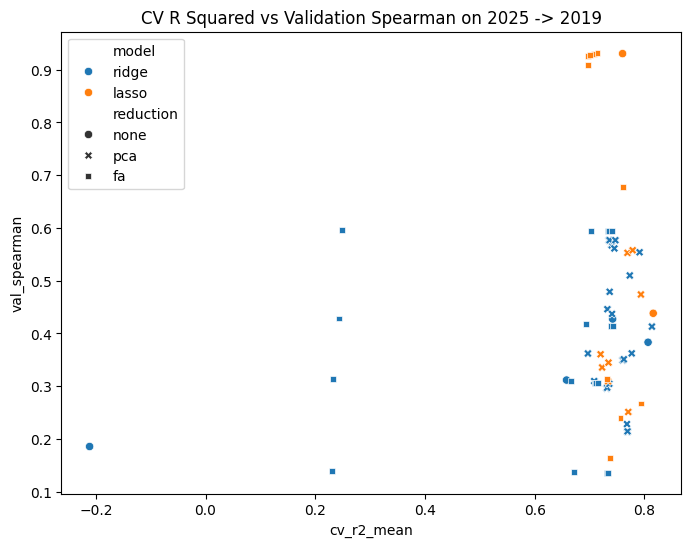

In [36]:
for direction in [dataset_pairs[date][0] for date in range(len(dataset_pairs))]:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=results_df[results_df["direction"] == direction],
        x="cv_r2_mean",
        y="val_spearman",
        hue="model",
        style="reduction"
    )
    plt.title(f"CV R Squared vs Validation Spearman on {direction}")
    plt.show()

These results are very interesting, especially since itwas observed that the targets across snapshots have a strong correlation with each other. On the side of model selection, it shows PCA and Ridge fall apart on the validation set with all top performing models being Lasso and none ofthem using PCA. On the side of snapshot directions, models trained on 2019 generalize well to 2025, preserving ranking structure, while models trained on 2025 show mixed and often degraded ranking performance when applied to 2019. Intuitively, I would have assumed that iftrain/validate metrics are good in one direction then they will likely be also in the opposite direction. This suggests there are some underlying structures or patterns in the 2019 dataset which are missing in 2025 to mean that training on 2019 and validating on 2025 scores well, but in the opposite direction these structures are missed. Having said that, as mentioned, Lasso still does well.

This indicates that sparsity is beneficial: by selecting a limited subset ofpredictive features, Lasso isolates signals that are stable across time and ignores weaker, time- specific correlations whereas Ridge maintains all features to some extent, even those who may only be predictive in one direction.

On FA outperforming PCA, this may be because FA aims to capture latent factors which may be stable across snapshots. Since PCA captures directions of maximal variance, this can include year-specific information more easily.

Overall, the possibility oftrain/validate splits on multiple snapshots seems plausible withsome models observed to perform well. That is as always, with the added guidance of scrutiny since as explained above some methods do struggle. This may also mean that care should be taken to use the better direction.

On further work:
1. Re-examine SLX models in contrast to Lasso/Ridge in the context ofmultiple
snapshots
2. Once multi-city datasets are available revisit the problem with more data
3. Explore tree-based modeling methods